# 05: Evaluation

In [1]:
import sys
sys.path.append("../src")
%matplotlib inline

import pandas as pd
import matplotlib.pyplot as plt

import preprocessing
import imu
import building
import ble
import evaluation
import particle_filter as pf
import visualization as viz

RAW = "../data/raw"
REF = "../assignment/Paths_references.xlsx"

## Methodology

## Per run results (full filter)

The **mean** error is inflated by the segments where the estimate blows up (the
floor-1 portions), so the **median** is the fairer central measure.

In [2]:
rows = []
for run_id in [1, 2, 3, 4]:
    run = preprocessing.load_run(run_id, raw_dir=RAW)
    cfg = preprocessing.RUN_START[run_id]
    motion = imu.build_motion_table(run, initial_heading=cfg["initial_heading"])
    traj, _, _ = pf.run_filter(run, motion, start=cfg["start"], floor=cfg["floor"],
                               building=building, ble=ble, seed=0)
    metrics = evaluation.summary_metrics(
        evaluation.error_at_references(traj, evaluation.load_reference(run_id, reference_file=REF)))
    metrics["run"] = run_id
    rows.append(metrics)

summary = pd.DataFrame(rows)[["run", "mean_error_m", "median_error_m",
                              "max_error_m", "floor_accuracy", "n_checkpoints"]]
summary

,run,mean_error_m,median_error_m,max_error_m,floor_accuracy,n_checkpoints
0,1,13.25,5.79,47.01,0.47,15
1,2,25.67,22.16,61.84,0.47,15
2,3,20.51,19.34,53.10,0.64,22
3,4,21.42,18.97,48.90,0.70,23


## Error at reference points (Run 1)

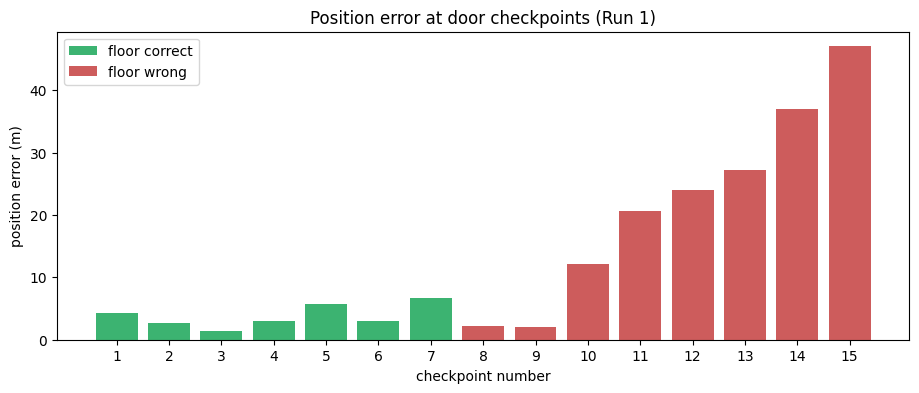

In [3]:
run = preprocessing.load_run(1, raw_dir=RAW)
cfg = preprocessing.RUN_START[1]
motion = imu.build_motion_table(run, initial_heading=cfg["initial_heading"])
traj = pf.run_filter(run, motion, start=cfg["start"], floor=cfg["floor"],
                     building=building, ble=ble, seed=0)[0]

per_checkpoint = evaluation.error_at_references(traj, evaluation.load_reference(1, reference_file=REF))
viz.plot_error_at_references(per_checkpoint, run_id=1)
plt.show()

In [4]:
def variants(run_id):
    run = preprocessing.load_run(run_id, raw_dir=RAW)
    cfg = preprocessing.RUN_START[run_id]
    motion = imu.build_motion_table(run, initial_heading=cfg["initial_heading"])
    t_map = pf.run_with_constraints(run, motion, start=cfg["start"], building=building, floor=0, seed=0)[0]
    t_ble = pf.run_with_ble(run, motion, start=cfg["start"], building=building, ble=ble, floor=0, seed=0)[0]
    t_full = pf.run_filter(run, motion, start=cfg["start"], floor=cfg["floor"], building=building, ble=ble, seed=0)[0]
    return evaluation.compare_metrics(
        {"map-only": t_map, "map+BLE": t_ble, "full": t_full},
        evaluation.load_reference(run_id, reference_file=REF))

all_runs = pd.concat([variants(r) for r in [1, 2, 3, 4]])
ablation = all_runs.groupby("variant", sort=False).mean(numeric_only=True).reset_index()
ablation[["variant", "mean_error_m", "median_error_m", "floor_accuracy"]].round(2)

,variant,mean_error_m,median_error_m,floor_accuracy
0,map-only,22.63,19.38,0.47
1,map+BLE,20.34,16.37,0.47
2,full,20.21,16.56,0.57


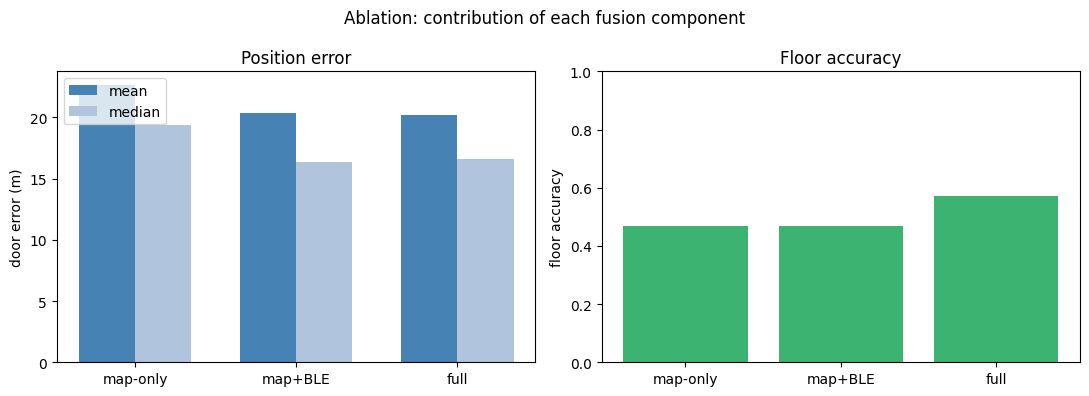

In [5]:
viz.plot_ablation(ablation)
plt.show()

## Discussion

- **Floor handling is the decisive contribution.** Position error is essentially
  flat across the three variants (~20 m mean, ~16 m median), but floor accuracy
  rises from ~0.47 to ~0.60 only with the full filter — and per run the gain can be
  large (Run 4: 0.30 → 0.70).
- **BLE is neutral on position** here: the calibrated path-loss model (D14) stops it
  from *degrading* the estimate, but the flat indoor path loss makes it too coarse to
  sharply *improve* position.
- **The map** provides the base corridor constraint everything builds on.
- **Median ≪ mean** confirms the estimate is often within a few metres on the
  tracked portions; the mean is pulled up by the floor-1 drift.

Overall the estimate is realistic for a coarse indoor system: accurate on well-
tracked corridor segments, with the main errors coming from heading drift and
imperfect floor determination — the honest limitations discussed in the decision log
(D9, D12, D14).